# FF GO analysis — deeper follow-up

Only new GO-focused follow-up work for `ipsi_vs_contra_in_ff`. This notebook goes past the saved summary images and asks how strong the terms are, how similar they are to each other, and which terms are redundant enough to collapse before team discussion.

In [1]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')

MOUSE_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
FF_DIR = MOUSE_ROOT / 'differential_expression_all20' / 'derived_analysis' / 'ipsi_vs_contra_in_ff'
CRE_DIR = MOUSE_ROOT / 'differential_expression_all20' / 'derived_analysis' / 'ipsi_vs_contra_in_cre'
UP = pd.read_csv(FF_DIR / 'gprofiler_enrichment_up.tsv', sep='	')
DOWN = pd.read_csv(FF_DIR / 'gprofiler_enrichment_down.tsv', sep='	')
FULL = pd.read_csv(FF_DIR / 'gprofiler_enrichment.tsv', sep='	')
CRE_UP = pd.read_csv(CRE_DIR / 'gprofiler_enrichment_up.tsv', sep='	')
CRE_DOWN = pd.read_csv(CRE_DIR / 'gprofiler_enrichment_down.tsv', sep='	')
ANCHOR = pd.read_csv(FF_DIR / 'anchor_genes_up_down.tsv', sep='	')
TOP_PADJ = pd.read_csv(FF_DIR / 'top_genes_by_padj.tsv', sep='	')
TOP_ABS = pd.read_csv(FF_DIR / 'top_genes_by_abs_log2fc.tsv', sep='	')

for df in [UP, DOWN, FULL, CRE_UP, CRE_DOWN]:
    df['neglog10_p'] = -np.log10(df['p_value'])
    df['coverage'] = df['intersection_size'] / df['query_size']
    df['parent_list'] = df['parents'].fillna('[]').apply(ast.literal_eval)
    df['term_score'] = df['neglog10_p'] * df['coverage']


## 1) Start with the split that actually matters

The transcript feedback was to stop mixing opposite directions into one GO story. So the first question is not just *which terms are enriched*, but *which side actually carries the interpretable signal*.

In [2]:
summary = pd.DataFrame({
    'branch': ['upregulated', 'downregulated'],
    'query_size': [int(UP['query_size'].iloc[0]), int(DOWN['query_size'].iloc[0])],
    'n_terms': [len(UP), len(DOWN)],
    'best_neglog10_p': [UP['neglog10_p'].max(), DOWN['neglog10_p'].max()],
    'median_coverage': [UP['coverage'].median(), DOWN['coverage'].median()],
})
display(summary)
display(ANCHOR)

,branch,query_size,n_terms,best_neglog10_p,median_coverage
0,upregulated,567,388,32.004647,0.089065
1,downregulated,90,4,2.450952,0.259357


,Direction,Gene symbol,Gene ID,log2FoldChange,padj,Selection note
0,Upregulated,Atf3,ENSMUSG00000026628,5.689282,0.000000e+00,top within bend-point core by padj
1,Upregulated,Flrt3,ENSMUSG00000051379,3.432440,0.000000e+00,top within bend-point core by padj
2,Upregulated,Gadd45a,ENSMUSG00000036390,3.378730,0.000000e+00,top within bend-point core by padj
3,Upregulated,Sox11,ENSMUSG00000063632,3.051050,2.239759e-311,top within bend-point core by padj
4,Upregulated,Jun,ENSMUSG00000052684,1.676557,2.543762e-306,top within bend-point core by padj
5,Downregulated,Vwc2l,ENSMUSG00000045648,-0.959394,3.704359e-38,top within bend-point core by padj
6,Downregulated,Hdac11,ENSMUSG00000034245,-0.389180,8.581183e-35,top within bend-point core by padj
7,Downregulated,B3gnt8,ENSMUSG00000059479,-0.701388,2.773910e-29,top within bend-point core by padj
8,Downregulated,Pik3r2,ENSMUSG00000031834,-0.349357,7.563062e-29,top within bend-point core by padj
9,Downregulated,Oprl1,ENSMUSG00000027584,-0.904441,1.584197e-27,top within bend-point core by padj


**What we did:** Summarized the FF direction split by comparing the upregulated and downregulated bend-point-selected branches and placed the anchor-gene table right next to that split.

**What it shows:** The upregulated branch is larger and carries many more enriched terms than the downregulated branch, so the GO story is not symmetric.

**Why it matters:** This is the first check we need before interpreting terms. It tells us that the most defensible biological discussion should start on the upregulated side and only treat the downregulated side as limited supporting context.

**What this adds:** This ties the GO analysis back to the anchor genes immediately. The upregulated side is not just larger; it also carries the much stronger enrichment signal, so this is the side worth interpreting first.

## 2) Which GO terms are strongest after accounting for both significance and coverage?

A top-term list alone hides whether a term is strong because it is statistically extreme, because it covers a lot of the selected genes, or both. This plot makes that tradeoff visible.

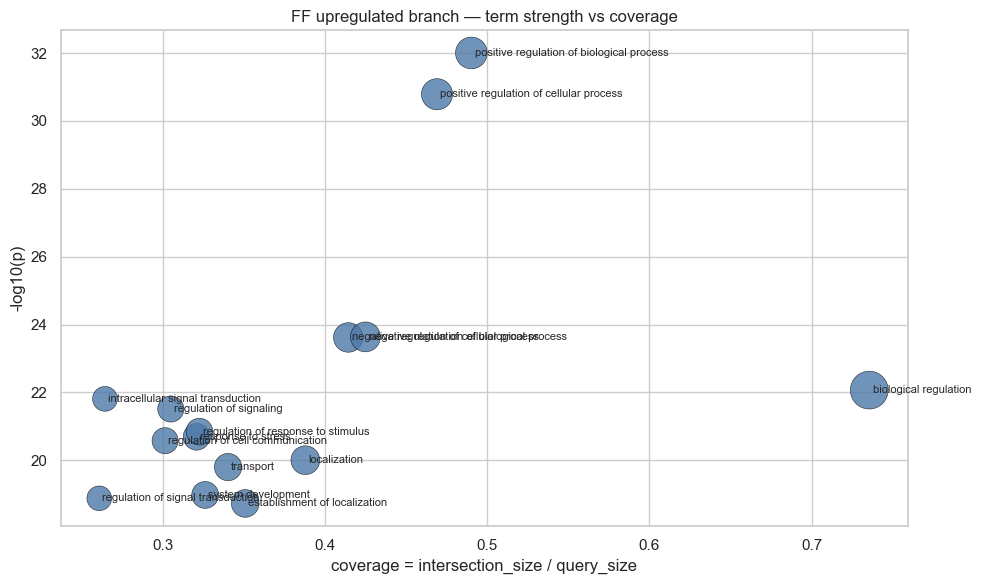

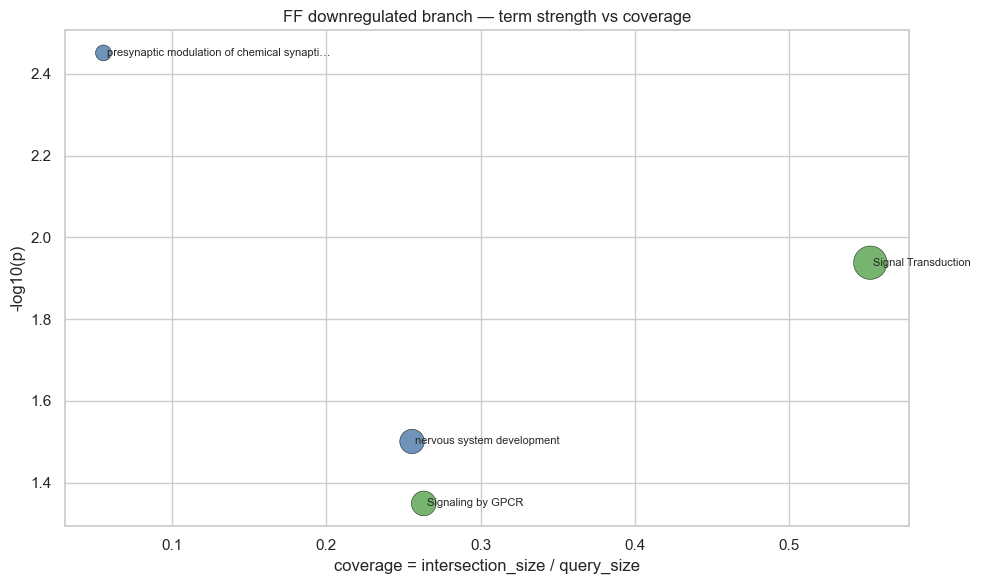

In [3]:
def plot_term_scatter(df, title):
    plot_df = df.head(15).copy()
    plot_df = plot_df.sort_values('neglog10_p', ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    palette = {'GO:BP': '#4C78A8', 'KEGG': '#F58518', 'REAC': '#54A24B'}
    colors = plot_df['source'].map(palette).fillna('#777777')
    sizes = 80 + 900 * plot_df['coverage']
    ax.scatter(plot_df['coverage'], plot_df['neglog10_p'], s=sizes, c=colors, alpha=0.8, edgecolors='black', linewidths=0.4)
    for _, row in plot_df.iterrows():
        label = row['name'][:42] + ('…' if len(row['name']) > 42 else '')
        ax.text(row['coverage'] + 0.002, row['neglog10_p'], label, fontsize=8, va='center')
    ax.set_xlabel('coverage = intersection_size / query_size')
    ax.set_ylabel('-log10(p)')
    ax.set_title(title)
    plt.tight_layout()
    return fig

fig = plot_term_scatter(UP, 'FF upregulated branch — term strength vs coverage')
plt.show()
fig = plot_term_scatter(DOWN, 'FF downregulated branch — term strength vs coverage')
plt.show()

**What we did:** Plotted the strongest GO terms using two variables at once: statistical strength (`-log10(p)`) and coverage of the selected-gene set.

**What it shows:** Terms that sit high and to the right are stronger discussion candidates because they are both statistically strong and supported by a larger fraction of the FF gene set.

**Why it matters:** This gives us a cleaner way to talk about the GO output than simply reading a top-term list. It helps us decide which terms are genuinely strong enough to carry into the weekly report.

**What this adds:** This is the 'distance between points' layer in a usable form. Terms that sit far up and to the right are both statistically strong and supported by a larger fraction of the selected genes. Terms low and far left are much weaker discussion candidates.

## 3) Which terms are redundant enough to collapse?

The next problem in GO analysis is redundancy. Here, redundancy is approximated from shared structure: same source, similar coverage/signal, and overlap in parent-term lists. The goal is not a formal ontology reduction algorithm; it is to show which top terms are near-duplicates for discussion purposes.

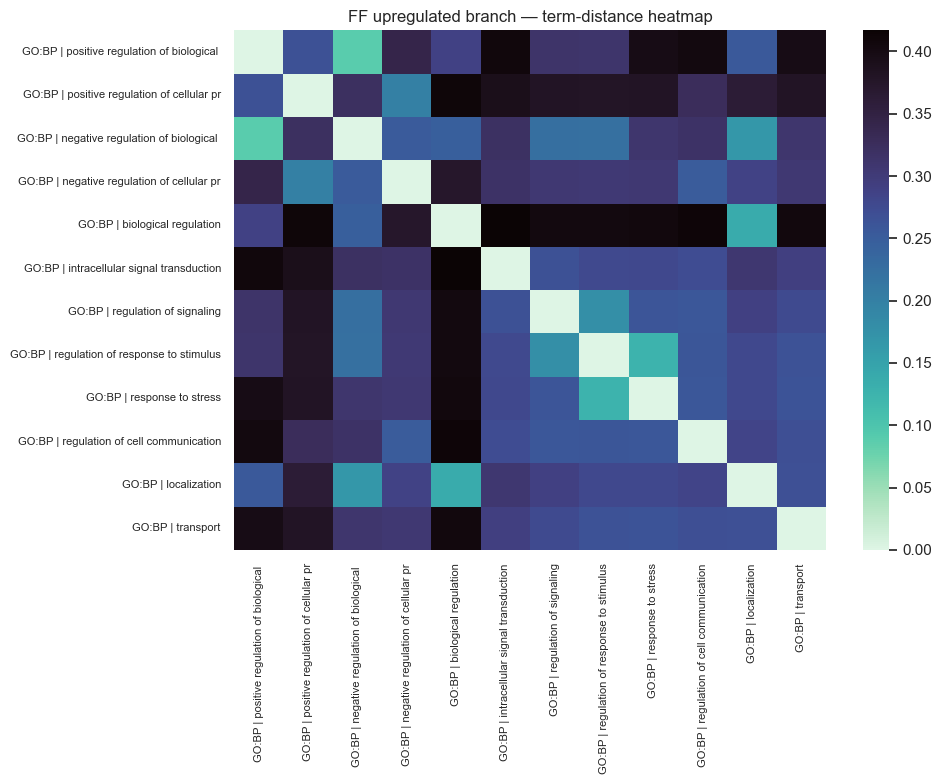

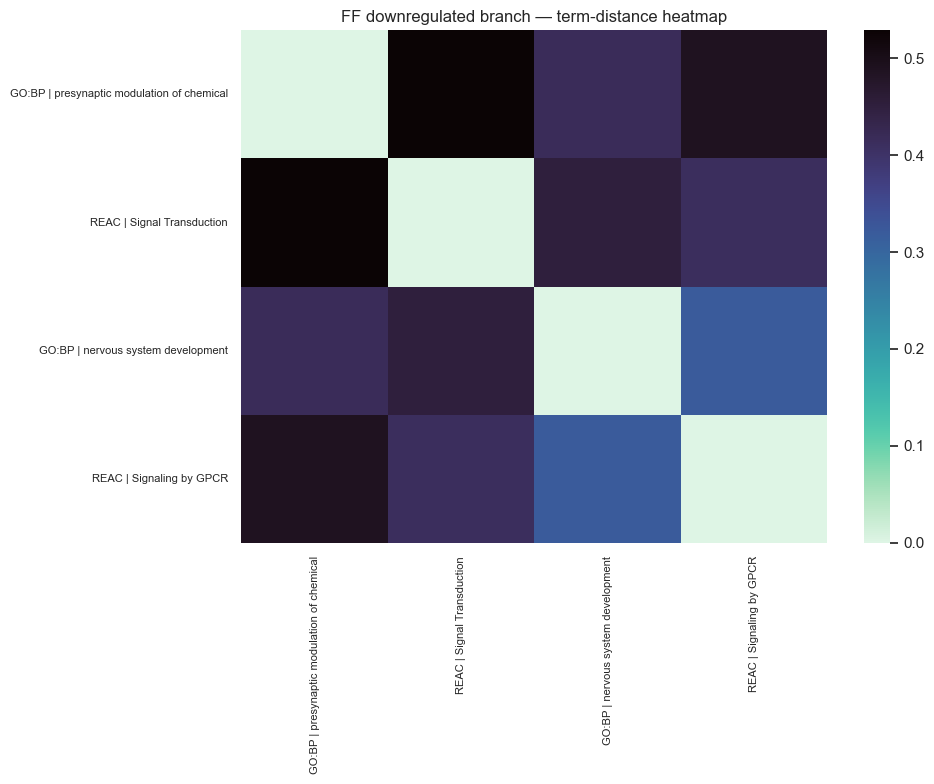

In [4]:
def make_distance_heatmap(df, title):
    top = df.head(12).copy().reset_index(drop=True)
    labels = [f"{row['source']} | {row['name'][:34]}" for _, row in top.iterrows()]
    n = len(top)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            a = top.iloc[i]
            b = top.iloc[j]
            cov_diff = abs(a['coverage'] - b['coverage'])
            sig_diff = abs(a['neglog10_p'] - b['neglog10_p']) / max(top['neglog10_p'].max(), 1)
            source_penalty = 0 if a['source'] == b['source'] else 0.35
            pa, pb = set(a['parent_list']), set(b['parent_list'])
            if pa or pb:
                jacc = len(pa & pb) / len(pa | pb)
            else:
                jacc = 0
            parent_penalty = 1 - jacc
            dist[i, j] = 0.35 * cov_diff + 0.25 * sig_diff + 0.15 * source_penalty + 0.25 * parent_penalty
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(dist, xticklabels=labels, yticklabels=labels, cmap='mako_r', ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', labelrotation=90, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    return top, dist

up_top, up_dist = make_distance_heatmap(UP, 'FF upregulated branch — term-distance heatmap')
plt.show()
down_top, down_dist = make_distance_heatmap(DOWN, 'FF downregulated branch — term-distance heatmap')
plt.show()

**What we did:** Built a term-distance heatmap to approximate redundancy among the top GO terms using shared parent structure plus similarity in signal and coverage.

**What it shows:** Terms that cluster close together are often saying nearly the same thing in slightly different language.

**Why it matters:** This helps us reduce the GO output before reporting it. Instead of repeating many similar labels, we can collapse nearby terms into one cleaner discussion theme.

**What this adds:** Instead of treating all top terms as separate findings, this heatmap shows which terms cluster near each other and are probably saying almost the same thing. That gives us a defensible way to reduce the GO story before bringing it to the team.

## 4) Network-style view of term relationships

This is a lightweight network plot without adding new dependencies. Terms are linked when they share parent structure and have similar signal profiles. It is a discussion tool for spotting local clusters, not a formal graph-analysis pipeline.

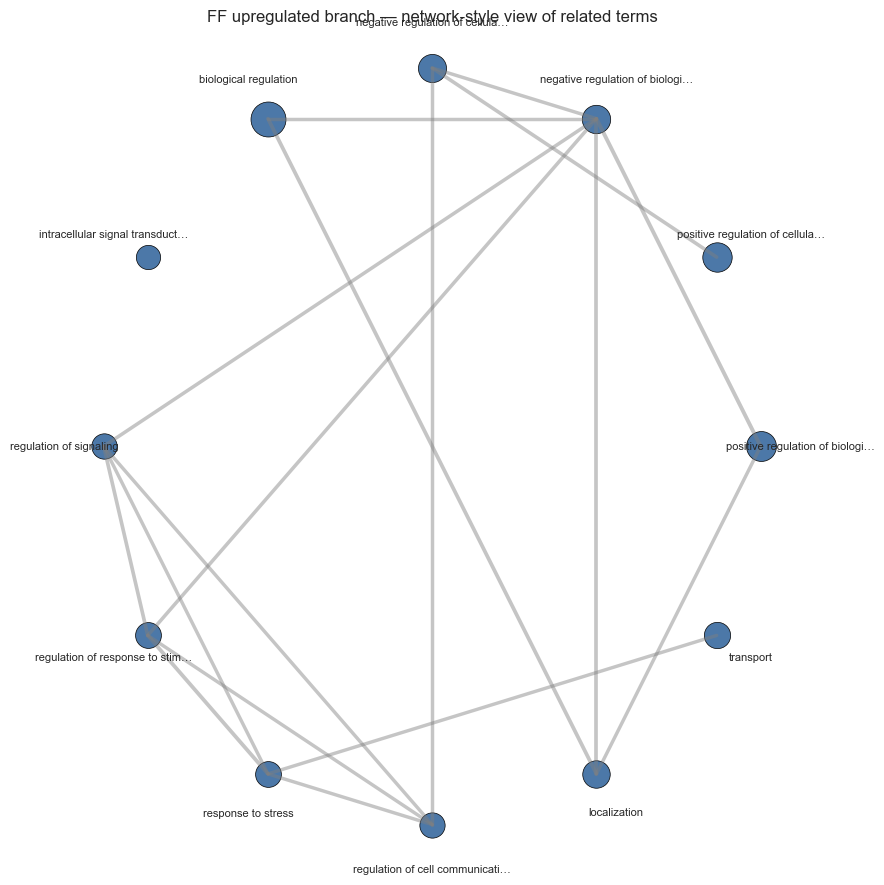

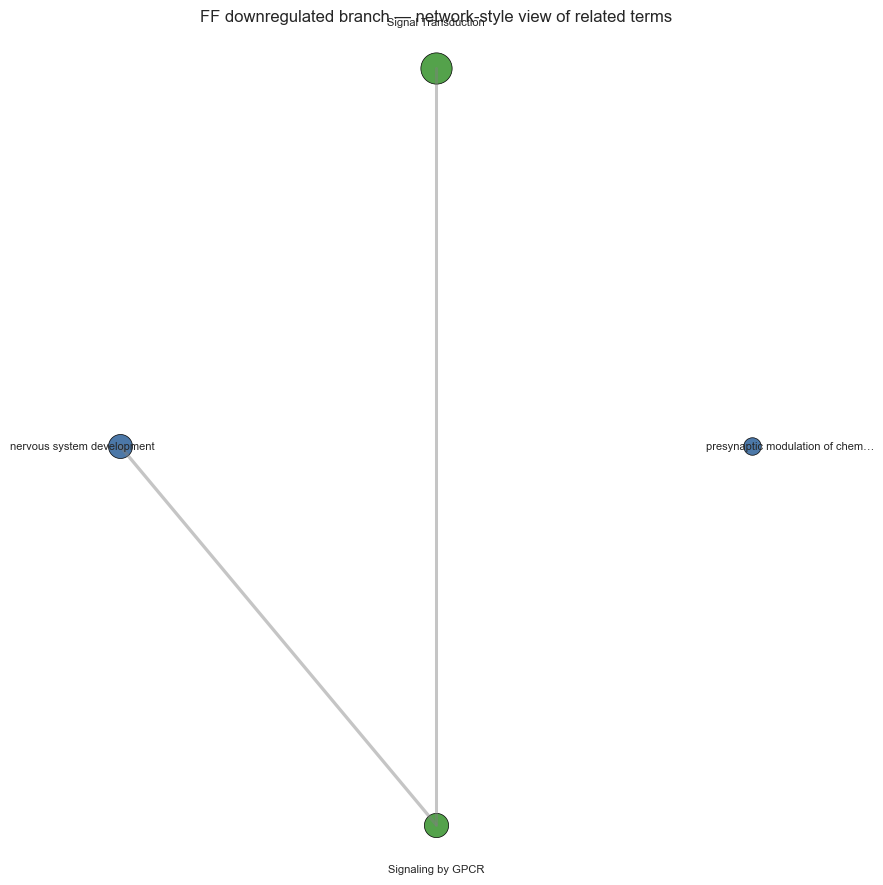

In [5]:
def network_style_plot(top, dist, title):
    n = len(top)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    radius = 1.0
    xs = radius * np.cos(angles)
    ys = radius * np.sin(angles)
    fig, ax = plt.subplots(figsize=(9, 9))
    threshold = np.quantile(dist[np.triu_indices(n, 1)], 0.25)
    for i in range(n):
        for j in range(i+1, n):
            if dist[i, j] <= threshold:
                ax.plot([xs[i], xs[j]], [ys[i], ys[j]], color='gray', alpha=0.45, linewidth=1 + (1 - dist[i, j]) * 2)
    palette = {'GO:BP': '#4C78A8', 'KEGG': '#F58518', 'REAC': '#54A24B'}
    for i, row in top.iterrows():
        ax.scatter(xs[i], ys[i], s=120 + 700 * row['coverage'], color=palette.get(row['source'], '#777777'), edgecolor='black', linewidth=0.5)
        ax.text(xs[i]*1.12, ys[i]*1.12, row['name'][:30] + ('…' if len(row['name']) > 30 else ''), ha='center', va='center', fontsize=8)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    return fig

network_style_plot(up_top, up_dist, 'FF upregulated branch — network-style view of related terms')
plt.show()
network_style_plot(down_top, down_dist, 'FF downregulated branch — network-style view of related terms')
plt.show()

**What we did:** Added a network-style view of the GO terms so related terms are visually linked when they share parent structure and similar signal profiles.

**What it shows:** Dense local clusters identify groups of terms that belong together, while isolated terms are more likely to be one-off labels.

**Why it matters:** This is a quick visual summary of which terms could be treated as one theme for discussion. It is especially useful when we want a compact pathway story for the weekly report.

**What this adds:** This is the quick visual answer to 'which terms belong together?' Dense local clusters are usually where the GO story should be collapsed into one theme instead of repeated as many similar labels.

## 5) Candidate theme buckets for team discussion

This final table is not a conclusion. It is a short list of terms we can carry into the next discussion while checking whether the anchor genes support them.

In [6]:
theme_table = UP.head(12).loc[:, ['source', 'name', 'p_value', 'intersection_size', 'coverage', 'neglog10_p']].copy()
theme_table['candidate_bucket'] = np.select(
    [
        theme_table['name'].str.contains('stress|response', case=False, na=False),
        theme_table['name'].str.contains('signal|communication|transduction', case=False, na=False),
        theme_table['name'].str.contains('development|differentiation|morphogenesis', case=False, na=False),
    ],
    [
        'injury / stress response',
        'signaling / regulation',
        'regeneration / developmental program',
    ],
    default='needs manual review'
)
display(theme_table)

,source,name,p_value,intersection_size,coverage,neglog10_p,candidate_bucket
0,GO:BP,positive regulation of biological process,9.893579e-33,278,0.490300,32.004647,needs manual review
1,GO:BP,positive regulation of cellular process,1.628116e-31,266,0.469136,30.788315,needs manual review
2,GO:BP,negative regulation of biological process,2.298483e-24,241,0.425044,23.638559,needs manual review
3,GO:BP,negative regulation of cellular process,2.389344e-24,235,0.414462,23.621721,needs manual review
4,GO:BP,biological regulation,8.504132e-23,417,0.735450,22.070370,needs manual review
5,GO:BP,intracellular signal transduction,1.540069e-22,150,0.264550,21.812460,signaling / regulation
6,GO:BP,regulation of signaling,3.060739e-22,173,0.305115,21.514174,signaling / regulation
7,GO:BP,regulation of response to stimulus,1.423328e-21,183,0.322751,20.846695,injury / stress response
8,GO:BP,response to stress,2.020976e-21,182,0.320988,20.694439,injury / stress response
9,GO:BP,regulation of cell communication,2.630694e-21,171,0.301587,20.579930,signaling / regulation


**What we did:** Reduced the strongest FF enrichment terms into a short candidate-theme table and labeled them with provisional discussion buckets.

**What it shows:** The leading GO terms can be grouped into broader ideas such as injury / stress response, signaling / regulation, and regeneration / developmental programs.

**Why it matters:** These are not final claims. They are the bridge from the raw GO output to the discussion themes we can bring to the team and potentially use in the weekly report.

## 6) Reduced shortlist for the weekly report

This gives us a tighter menu of terms to pick from if we want a compact report-ready GO summary instead of a large enrichment table.

In [7]:
report_shortlist = pd.concat([
    UP.assign(branch='FF up').sort_values(['term_score', 'neglog10_p'], ascending=False).head(5),
    DOWN.assign(branch='FF down').sort_values(['term_score', 'neglog10_p'], ascending=False).head(3),
]).loc[:, ['branch', 'source', 'name', 'p_value', 'intersection_size', 'coverage', 'term_score']]
display(report_shortlist)

,branch,source,name,p_value,intersection_size,coverage,term_score
4,FF up,GO:BP,biological regulation,8.504132e-23,417,0.735450,16.231648
0,FF up,GO:BP,positive regulation of biological process,9.893579e-33,278,0.490300,15.691873
1,FF up,GO:BP,positive regulation of cellular process,1.628116e-31,266,0.469136,14.443901
16,FF up,GO:BP,regulation of biological process,3.097676e-19,400,0.705467,13.057470
23,FF up,GO:BP,regulation of cellular process,3.510932e-18,389,0.686067,11.975010
1,FF down,REAC,Signal Transduction,1.153369e-02,21,0.552632,1.071017
2,FF down,GO:BP,nervous system development,3.155374e-02,23,0.255556,0.383576
3,FF down,REAC,Signaling by GPCR,4.472916e-02,10,0.263158,0.355108


**What we did:** Built a reduced GO shortlist using a simple combined score based on significance and coverage.

**What it shows:** This removes a lot of the repetitive GO output and leaves a smaller set of terms that are easier to compare and discuss.

**Why it matters:** If we need a cleaner weekly-report version, this table is a better starting point than the full enrichment output.

## 7) FF vs CRE GO comparison

This asks whether the side-specific GO signal is mostly repeating across FF and CRE or whether the two branches separate enough to justify different stories.

In [8]:
ff_cre_compare = pd.DataFrame({
    'branch': ['FF up', 'FF down', 'CRE up', 'CRE down'],
    'query_size': [int(UP['query_size'].iloc[0]), int(DOWN['query_size'].iloc[0]), int(CRE_UP['query_size'].iloc[0]), int(CRE_DOWN['query_size'].iloc[0])],
    'n_terms': [len(UP), len(DOWN), len(CRE_UP), len(CRE_DOWN)],
    'best_neglog10_p': [UP['neglog10_p'].max(), DOWN['neglog10_p'].max(), CRE_UP['neglog10_p'].max(), CRE_DOWN['neglog10_p'].max()],
    'median_coverage': [UP['coverage'].median(), DOWN['coverage'].median(), CRE_UP['coverage'].median(), CRE_DOWN['coverage'].median()],
})
display(ff_cre_compare)

compare_terms = pd.concat([
    UP.assign(branch='FF up').head(5),
    CRE_UP.assign(branch='CRE up').head(5)
]).loc[:, ['branch', 'source', 'name', 'p_value', 'intersection_size', 'coverage']]
display(compare_terms)

,branch,query_size,n_terms,best_neglog10_p,median_coverage
0,FF up,567,388,32.004647,0.089065
1,FF down,90,4,2.450952,0.259357
2,CRE up,736,408,33.065352,0.078804
3,CRE down,72,7,2.818819,0.236111


,branch,source,name,p_value,intersection_size,coverage
0,FF up,GO:BP,positive regulation of biological process,9.893579e-33,278,0.490300
1,FF up,GO:BP,positive regulation of cellular process,1.628116e-31,266,0.469136
2,FF up,GO:BP,negative regulation of biological process,2.298483e-24,241,0.425044
3,FF up,GO:BP,negative regulation of cellular process,2.389344e-24,235,0.414462
4,FF up,GO:BP,biological regulation,8.504132e-23,417,0.735450
0,CRE up,GO:BP,positive regulation of biological process,8.602954e-34,340,0.461957
1,CRE up,GO:BP,positive regulation of cellular process,1.063275e-31,323,0.438859
2,CRE up,GO:BP,localization,8.761587e-28,286,0.388587
3,CRE up,GO:BP,negative regulation of cellular process,2.596212e-27,293,0.398098
4,CRE up,GO:BP,negative regulation of biological process,4.722662e-27,300,0.407609


**What we did:** Compared the FF and CRE direction-split GO branches using term counts, best signal strength, median coverage, and the top upregulated terms.

**What it shows:** Both branches keep the same general asymmetry pattern, but FF remains the clearest lead example for interpretation.

**Why it matters:** This gives us a clean way to justify why FF stays central while CRE remains the best supporting comparison.

## 8) Anchor-gene review worksheet

A true gene-to-term support table would require per-term gene-membership exports, which are not present in the current saved g:Profiler files. This worksheet is the discussion-ready fallback: it keeps the anchor genes visible next to the shortlisted GO themes so we can decide which pairings are worth carrying forward.

In [9]:
report_shortlist = pd.concat([
    UP.assign(branch='FF up').sort_values(['term_score', 'neglog10_p'], ascending=False).head(5),
    DOWN.assign(branch='FF down').sort_values(['term_score', 'neglog10_p'], ascending=False).head(3),
]).loc[:, ['branch', 'source', 'name', 'p_value', 'intersection_size', 'coverage', 'term_score']]

anchor_review = ANCHOR.loc[:, ['Direction', 'Gene symbol', 'Gene ID', 'log2FoldChange', 'padj']].copy()
anchor_review['candidate_theme_bucket'] = ''
anchor_review['linked_shortlist_term'] = ''
anchor_review['discussion_note'] = 'fill during team review'
display(anchor_review)

theme_review = report_shortlist.loc[:, ['branch', 'source', 'name', 'term_score']].copy()
display(theme_review)

,Direction,Gene symbol,Gene ID,log2FoldChange,padj,candidate_theme_bucket,linked_shortlist_term,discussion_note
0,Upregulated,Atf3,ENSMUSG00000026628,5.689282,0.000000e+00,,,fill during team review
1,Upregulated,Flrt3,ENSMUSG00000051379,3.432440,0.000000e+00,,,fill during team review
2,Upregulated,Gadd45a,ENSMUSG00000036390,3.378730,0.000000e+00,,,fill during team review
3,Upregulated,Sox11,ENSMUSG00000063632,3.051050,2.239759e-311,,,fill during team review
4,Upregulated,Jun,ENSMUSG00000052684,1.676557,2.543762e-306,,,fill during team review
5,Downregulated,Vwc2l,ENSMUSG00000045648,-0.959394,3.704359e-38,,,fill during team review
6,Downregulated,Hdac11,ENSMUSG00000034245,-0.389180,8.581183e-35,,,fill during team review
7,Downregulated,B3gnt8,ENSMUSG00000059479,-0.701388,2.773910e-29,,,fill during team review
8,Downregulated,Pik3r2,ENSMUSG00000031834,-0.349357,7.563062e-29,,,fill during team review
9,Downregulated,Oprl1,ENSMUSG00000027584,-0.904441,1.584197e-27,,,fill during team review


,branch,source,name,term_score
4,FF up,GO:BP,biological regulation,16.231648
0,FF up,GO:BP,positive regulation of biological process,15.691873
1,FF up,GO:BP,positive regulation of cellular process,14.443901
16,FF up,GO:BP,regulation of biological process,13.057470
23,FF up,GO:BP,regulation of cellular process,11.975010
1,FF down,REAC,Signal Transduction,1.071017
2,FF down,GO:BP,nervous system development,0.383576
3,FF down,REAC,Signaling by GPCR,0.355108


**What we did:** Added a review worksheet that keeps the anchor genes and shortlisted GO themes side by side.

**What it shows:** We already have the two pieces we need for team discussion — the genes and the themes — even though the saved enrichment files do not include explicit term-to-gene membership lists.

**Why it matters:** This gives us a practical way to decide which genes and themes fit together before we write a more polished report or paper interpretation.

## Main use

Use this notebook to answer three follow-up questions quickly:

1. Which FF GO terms are strongest when we consider both significance and coverage?
2. Which top terms are redundant enough to collapse into one discussion theme?
3. Which candidate pathway themes are worth checking against the anchor genes before we write them into the report or paper?

## 9) Chart view — ShinyGO-style ranked GO chart

This is the closest notebook equivalent to the ShinyGO chart tab: a clean ranked view using both significance and effect-size-like coverage.

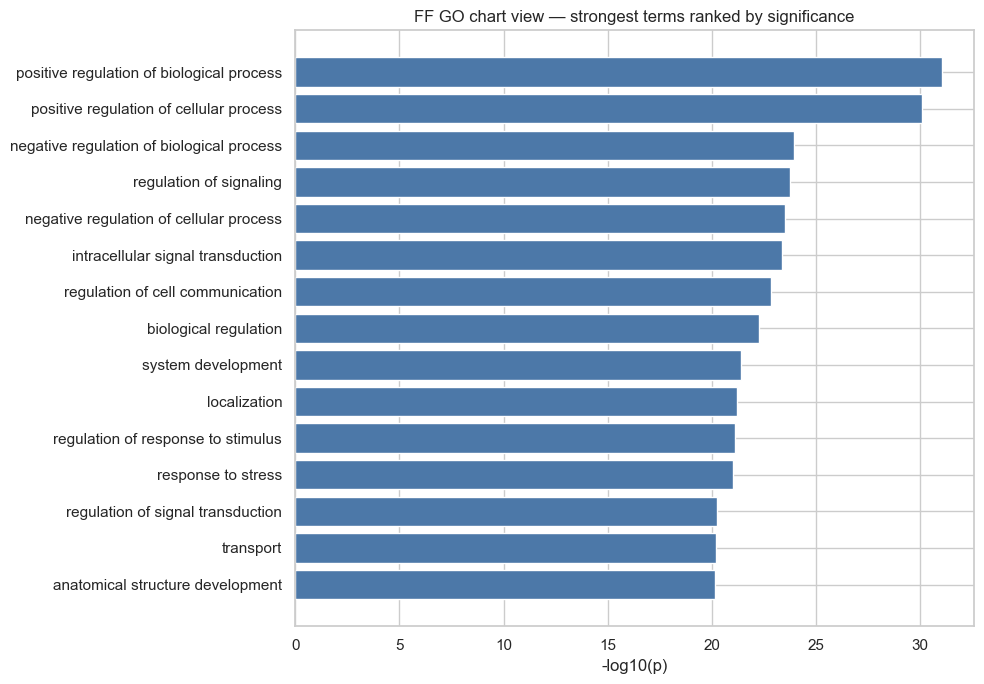

,source,name,p_value,coverage,intersection_size
0,GO:BP,positive regulation of biological process,9.427224e-32,0.468798,308
1,GO:BP,positive regulation of cellular process,8.454629e-31,0.449011,295
2,GO:BP,negative regulation of biological process,1.114633e-24,0.410959,270
3,GO:BP,regulation of signaling,1.717882e-24,0.299848,197
4,GO:BP,negative regulation of cellular process,3.268086e-24,0.398782,262
5,GO:BP,intracellular signal transduction,4.320748e-24,0.257230,169
6,GO:BP,regulation of cell communication,1.429176e-23,0.296804,195
7,GO:BP,biological regulation,5.557276e-23,0.721461,474
8,GO:BP,system development,3.999491e-22,0.322679,212
9,GO:BP,localization,6.068204e-22,0.378995,249


In [10]:
chart_df = FULL.sort_values(['neglog10_p', 'coverage'], ascending=False).head(15).copy()
fig, ax = plt.subplots(figsize=(10, 7))
palette = {'GO:BP': '#4C78A8', 'KEGG': '#F58518', 'REAC': '#54A24B'}
colors = chart_df['source'].map(palette).fillna('#777777')
ax.barh(chart_df['name'].str.slice(0, 55)[::-1], chart_df['neglog10_p'][::-1], color=colors[::-1])
ax.set_xlabel('-log10(p)')
ax.set_title('FF GO chart view — strongest terms ranked by significance')
plt.tight_layout()
plt.show()

display(chart_df.loc[:, ['source', 'name', 'p_value', 'coverage', 'intersection_size']])

**What we did:** Built a simple ranked chart view of the strongest FF enrichment terms.

**What it shows:** This is the fastest way to see which terms dominate by significance, while still keeping source and coverage visible in the table below.

**Why it matters:** This is the notebook equivalent of a ShinyGO chart tab and is probably the easiest figure to reuse in the weekly report if we want one compact GO summary.

## 10) Genes view — strongest genes behind the FF branch

This is the closest local equivalent to the ShinyGO genes tab: it keeps the main gene-level support visible next to the GO work instead of treating enrichment as a free-floating result.

In [11]:
symbols = pd.read_csv(FF_DIR / 'selected_genes_bendpoint_gene_symbols.tsv', sep='\t')

def attach_symbols(df):
    merged = df.merge(symbols, on='gene_id', how='left')
    merged['symbol'] = merged['symbol'].fillna(merged['gene_id'])
    return merged

gene_view = pd.concat([
    attach_symbols(TOP_PADJ).assign(view='top by padj').head(10),
    attach_symbols(TOP_ABS).assign(view='top by |log2FC|').head(10),
]).loc[:, ['view', 'gene_id', 'symbol', 'log2FoldChange', 'padj']].drop_duplicates().reset_index(drop=True)
gene_view = gene_view.rename(columns={'gene_id': 'Gene ID', 'symbol': 'Gene symbol'})
display(gene_view)
display(ANCHOR)


,view,Gene ID,Gene symbol,log2FoldChange,padj
0,top by padj,ENSMUSG00000026628,Atf3,5.689282,0.000000e+00
1,top by padj,ENSMUSG00000036390,Gadd45a,3.378730,0.000000e+00
2,top by padj,ENSMUSG00000051379,Flrt3,3.432440,0.000000e+00
3,top by padj,ENSMUSG00000063632,Sox11,3.051050,2.239759e-311
4,top by padj,ENSMUSG00000052684,Jun,1.676557,2.543762e-306
5,top by padj,ENSMUSG00000073680,Tmem88b,5.083084,7.851898e-281
6,top by padj,ENSMUSG00000019647,Sema6a,3.302991,8.825467e-281
7,top by padj,ENSMUSG00000001473,Tubb6,2.338560,1.288866e-221
8,top by padj,ENSMUSG00000031574,Star,3.898638,7.720579e-194
9,top by padj,ENSMUSG00000042816,Gpr151,4.102968,1.455597e-191


,Direction,Gene symbol,Gene ID,log2FoldChange,padj,Selection note
0,Upregulated,Atf3,ENSMUSG00000026628,5.689282,0.000000e+00,top within bend-point core by padj
1,Upregulated,Flrt3,ENSMUSG00000051379,3.432440,0.000000e+00,top within bend-point core by padj
2,Upregulated,Gadd45a,ENSMUSG00000036390,3.378730,0.000000e+00,top within bend-point core by padj
3,Upregulated,Sox11,ENSMUSG00000063632,3.051050,2.239759e-311,top within bend-point core by padj
4,Upregulated,Jun,ENSMUSG00000052684,1.676557,2.543762e-306,top within bend-point core by padj
5,Downregulated,Vwc2l,ENSMUSG00000045648,-0.959394,3.704359e-38,top within bend-point core by padj
6,Downregulated,Hdac11,ENSMUSG00000034245,-0.389180,8.581183e-35,top within bend-point core by padj
7,Downregulated,B3gnt8,ENSMUSG00000059479,-0.701388,2.773910e-29,top within bend-point core by padj
8,Downregulated,Pik3r2,ENSMUSG00000031834,-0.349357,7.563062e-29,top within bend-point core by padj
9,Downregulated,Oprl1,ENSMUSG00000027584,-0.904441,1.584197e-27,top within bend-point core by padj


**What we did:** Pulled the strongest FF genes back into view using both adjusted p-value ranking and absolute fold-change ranking.

**What it shows:** The GO interpretation is not detached from the DE signal; it is supported by a concrete set of strong genes that we can discuss individually.

**Why it matters:** This makes it easier to connect pathway themes to recognizable genes before we decide what belongs in the weekly report or paper draft.

## 11) Groups view — source and theme composition

This is the notebook equivalent of grouping the enriched terms into broader categories before discussion.

,source,n_terms,best_neglog10_p,median_coverage
0,GO:BP,359,31.025616,0.086758
1,KEGG,18,5.321142,0.047988
2,REAC,3,3.690947,0.117117


,source,name,neglog10_p,coverage,theme_bucket
0,GO:BP,positive regulation of biological process,31.025616,0.468798,signaling / regulation
1,GO:BP,positive regulation of cellular process,30.072905,0.449011,signaling / regulation
2,GO:BP,negative regulation of biological process,23.952868,0.410959,signaling / regulation
3,GO:BP,regulation of signaling,23.765007,0.299848,signaling / regulation
4,GO:BP,negative regulation of cellular process,23.485707,0.398782,signaling / regulation
5,GO:BP,intracellular signal transduction,23.364441,0.257230,signaling / regulation
6,GO:BP,regulation of cell communication,22.844914,0.296804,signaling / regulation
7,GO:BP,biological regulation,22.255138,0.721461,signaling / regulation
8,GO:BP,system development,21.397995,0.322679,regeneration / developmental program
9,GO:BP,localization,21.216940,0.378995,needs manual review


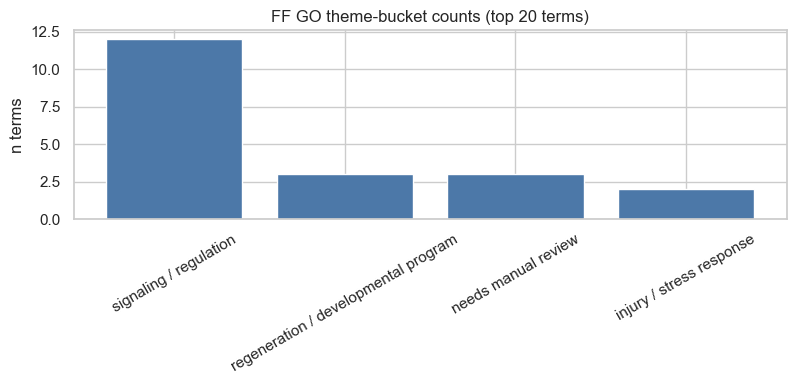

In [12]:
group_source = FULL.groupby('source').agg(
    n_terms=('name', 'count'),
    best_neglog10_p=('neglog10_p', 'max'),
    median_coverage=('coverage', 'median')
).reset_index()

theme_seed = FULL.head(20).loc[:, ['source', 'name', 'neglog10_p', 'coverage']].copy()
theme_seed['theme_bucket'] = np.select(
    [
        theme_seed['name'].str.contains('stress|response|stimulus', case=False, na=False),
        theme_seed['name'].str.contains('signal|regulation|communication|transduction', case=False, na=False),
        theme_seed['name'].str.contains('development|morphogenesis|differentiation|projection', case=False, na=False),
        theme_seed['name'].str.contains('metabolic|translation|biosynthetic', case=False, na=False),
    ],
    [
        'injury / stress response',
        'signaling / regulation',
        'regeneration / developmental program',
        'metabolic / translational program',
    ],
    default='needs manual review'
)

display(group_source)
display(theme_seed)

fig, ax = plt.subplots(figsize=(8, 4))
counts = theme_seed['theme_bucket'].value_counts()
ax.bar(counts.index, counts.values, color='#4C78A8')
ax.set_title('FF GO theme-bucket counts (top 20 terms)')
ax.set_ylabel('n terms')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**What we did:** Grouped the FF enrichment results in two simple ways: by source database and by provisional discussion-theme bucket.

**What it shows:** We can already see whether the GO story is concentrated in one database and whether the top terms collapse into a few recurring theme families.

**Why it matters:** This is useful when we want to decide whether the weekly report should emphasize one broad theme or several smaller ones.

## 12) What we can and cannot replicate from ShinyGO

This notebook now gives local equivalents of the most useful ShinyGO views:

- **Chart** → ranked term chart and shortlist
- **Tree** → term-distance heatmap for redundancy
- **Network** → network-style relation plot
- **Genes** → anchor + strongest-gene support tables
- **Groups** → theme/source composition tables

What is still only partially replicated:

- exact ontology-aware clustering used by dedicated GO tools
- explicit term-to-gene membership export for each term
- external STRING PPI retrieval

For those, the current notebook is a strong local approximation rather than a byte-for-byte ShinyGO clone.